<a href="https://colab.research.google.com/github/shivanshi-09/Introduction-to-Machine-Learning-/blob/main/A1_B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset("fashion_mnist")

## Logistic Regression Model

We model the probability of each class using a linear function followed by the **softmax function**.

First, the linear model computes class scores:

$$ z = XW + b $$


where

* (X) is the input feature matrix (flattened images)
* (W) is the weight matrix
* (b) is the bias vector

These scores are converted into probabilities using **softmax**:

$$
\hat{y}*k =
\frac{e^{z_k}}{\sum*{j=1}^{K} e^{z_j}}
$$

where (K) is the number of classes (10 for Fashion-MNIST).



In [8]:
train = dataset["train"]
test = dataset["test"]

x_train = np.array(train["image"])
y_train = np.array(train["label"])

x_test = np.array(test["image"])
y_test = np.array(test["label"])

#flatten by making the entire image one vector
#[28*28 since each image is those dimensions]
# divided by 255 to normalise between 0 and 1 since pixel colors are between 0 and 255
x_train = x_train.reshape(-1, 28*28)/255.0
x_test = x_test.reshape(-1, 28*28)/255.0

#create vectors of length 10 with only the correct class = 1
#makes y from n to n x 10
num_classes = 10
def one_hot(y, num_classes):
  return np.eye(num_classes)[y]
y_train = one_hot(y_train, 10)
y_test = one_hot(y_test, 10)


In [9]:
W = np.random.randn(784, 10) *0.01
b = np.zeros(10)

def softmax(z):
  z = z- np.max(z, axis = 1, keepdims = True)
  exp = np.exp(z)
  return exp / np.sum(exp, axis = 1, keepdims = True)

def forward(X, W, b):
  z = X @ W + b
  return softmax(z)

## Loss Function

We train the model using the **cross-entropy loss**:

$$
L = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K}
y_{ik}\log(\hat{y}_{ik})
$$

where

* $y_{ik}$ is the true one-hot encoded label
* $\hat{y}_{ik}$ is the predicted probability.

In [10]:
def compute_loss(Y, Y_hat):
  n = Y.shape[0]
  return -np.sum(Y* np.log(Y_hat + 1e-9))/n

def compute_gradients( X, Y, Y_hat):
  n = X.shape[0]
  dz = Y_hat - Y
  dW = (X.T @ dz)/n
  db = np.mean(dz, axis = 0)
  return dW, db

## Optimization

The parameters W and b are updated using gradient descent:

$$
W := W - \alpha \frac{\partial L}{\partial W}
$$

$$
b := b - \alpha \frac{\partial L}{\partial b}
$$

where $\alpha$ is the learning rate.

In [21]:
def train (X, Y, W, b, epochs = 100, learning_rate = 0.1):
  losses = []
  for epoch in range(epochs):
    Y_hat = forward(X, W, b)
    loss = compute_loss(Y, Y_hat)
    losses.append(loss)
    dW, db = compute_gradients(X, Y, Y_hat)
    W -=learning_rate *dW
    b -=learning_rate *db
    if epoch % 5 == 0:
      print (f"Epoch: {epoch}, Loss: {loss}")
  return W, b, losses

W, b, losses = train(x_train, y_train, W, b)

Epoch: 0, Loss: 0.5576781438966188
Epoch: 5, Loss: 0.5563875388063761
Epoch: 10, Loss: 0.5551286474639303
Epoch: 15, Loss: 0.5538993444633956
Epoch: 20, Loss: 0.5526977806838594
Epoch: 25, Loss: 0.5515223357451641
Epoch: 30, Loss: 0.5503715799097444
Epoch: 35, Loss: 0.5492442433049061
Epoch: 40, Loss: 0.5481391908818695
Epoch: 45, Loss: 0.5470554019156578
Epoch: 50, Loss: 0.5459919531309799
Epoch: 55, Loss: 0.544948004745744
Epoch: 60, Loss: 0.5439227888776161
Epoch: 65, Loss: 0.5429155998751426
Epoch: 70, Loss: 0.541925786223776
Epoch: 75, Loss: 0.5409527437459224
Epoch: 80, Loss: 0.5399959098679866
Epoch: 85, Loss: 0.5390547587699719
Epoch: 90, Loss: 0.5381287972671525
Epoch: 95, Loss: 0.5372175613005845


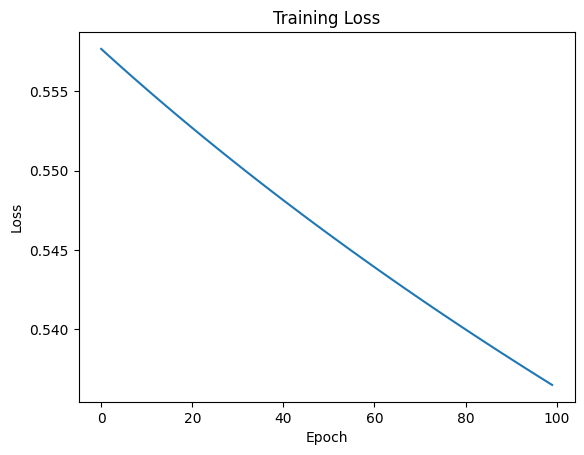

100


In [22]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()
print(len(losses))

In [23]:
def predict(X, W, b):
  probs = forward(X, W, b)
  return np.argmax(probs, axis = 1)
y_pred = predict(x_test, W, b)
y_true = np.argmax(y_test, axis = 1)
accuracy = np.mean(y_pred == y_true)
print("Test accuracy: ", accuracy)

Test accuracy:  0.8122


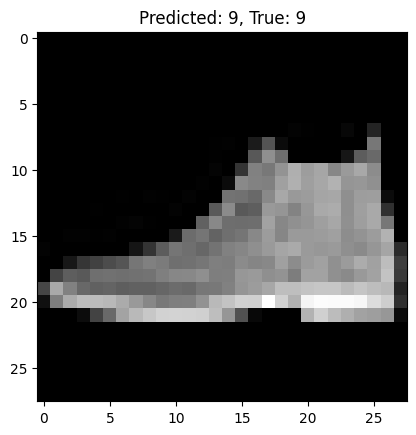

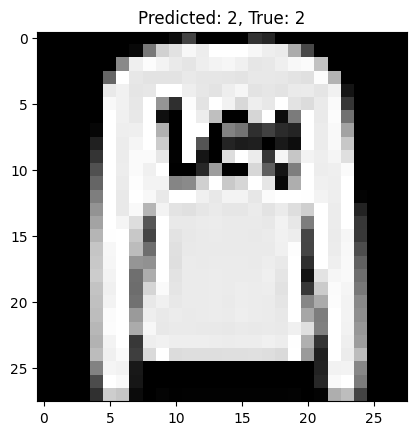

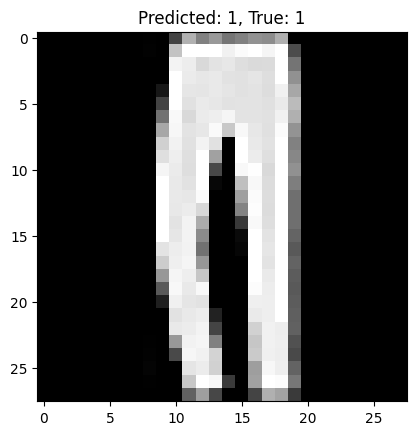

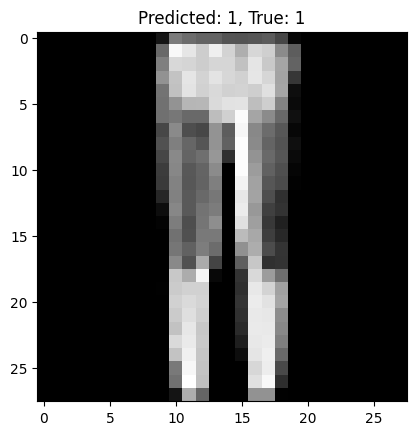

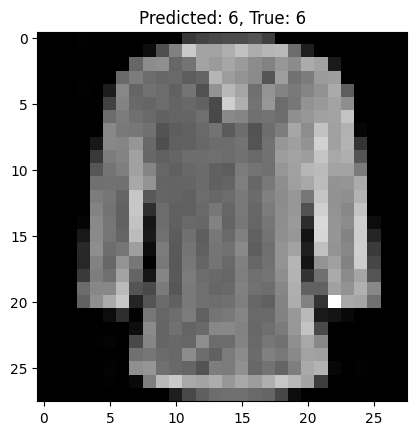

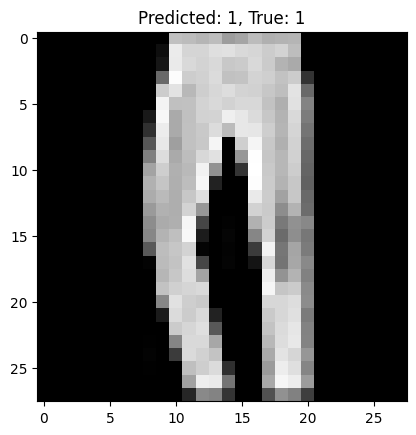

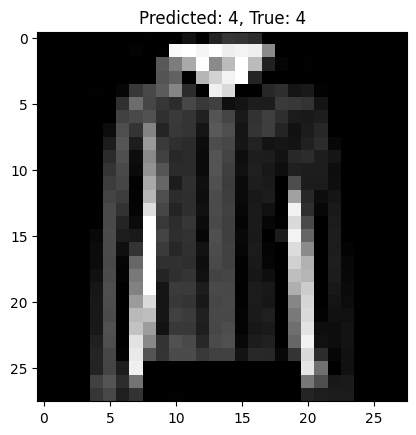

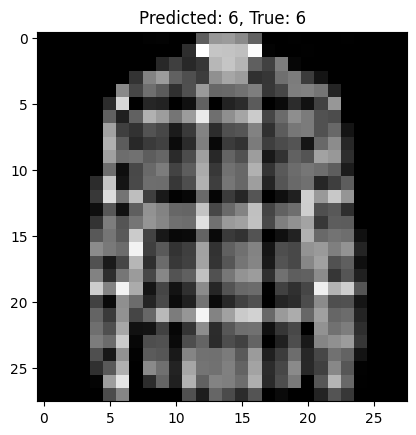

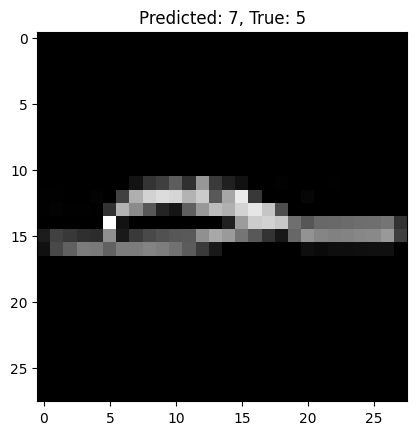

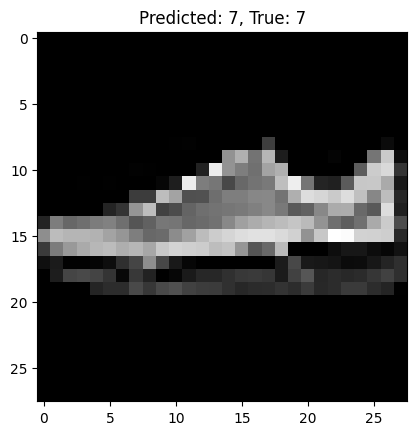

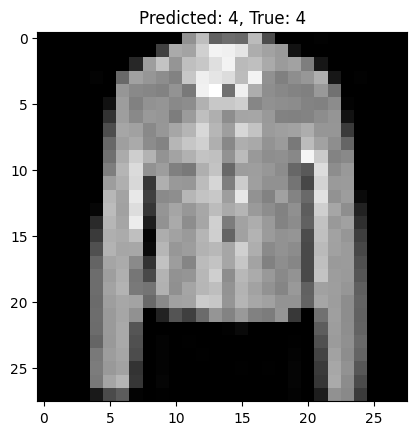

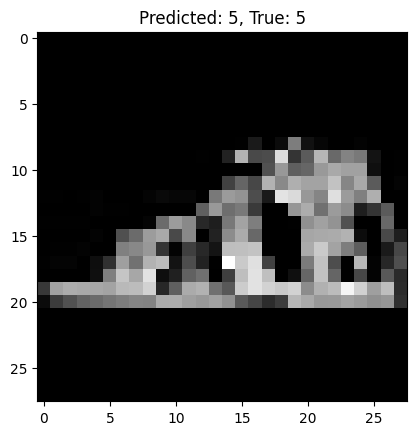

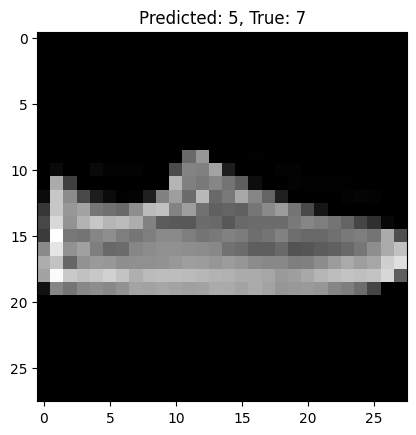

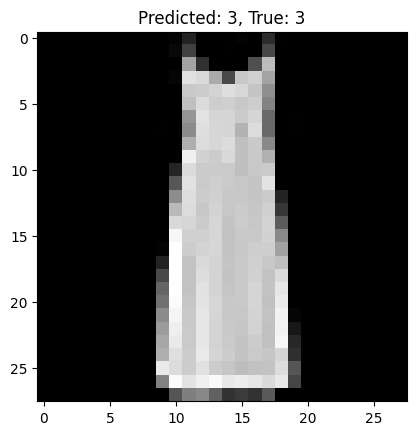

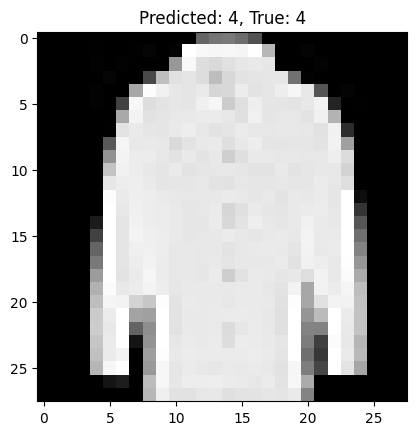

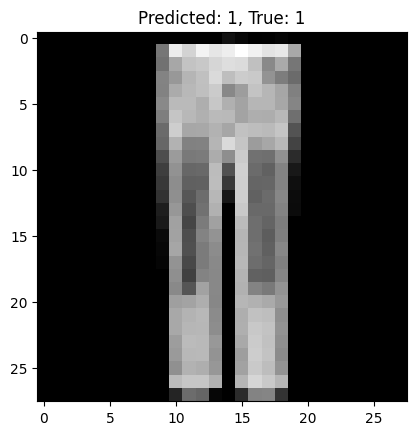

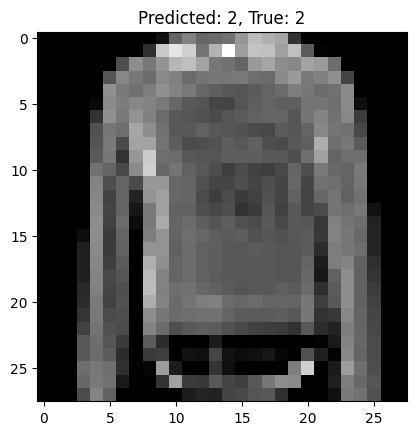

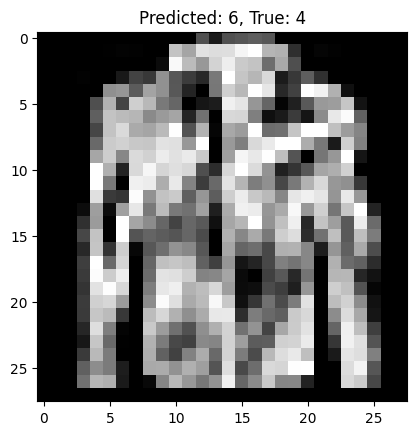

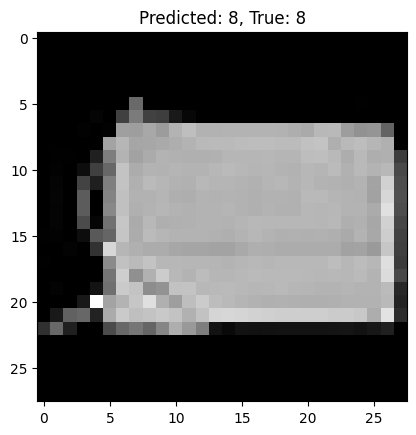

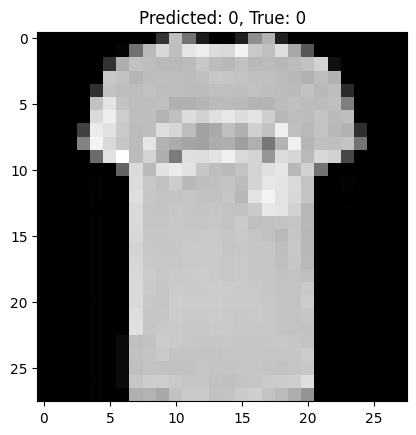

In [24]:
for i in range (20):
  true_label = np.argmax(y_test[i])
  plt.imshow(x_test[i].reshape(28, 28), cmap = "gray")
  plt.title(f"Predicted: {y_pred[i]}, True: {true_label}")
  plt.show()